In [1]:
#install necessary libraries
!pip install opendatasets pandas numpy scikit-learn xgboost --quiet

In [2]:
#import libraries
import opendatasets as od
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error
from xgboost import XGBClassifier, XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
datasetUrl = "https://www.kaggle.com/c/new-york-city-taxi-fare-prediction"
od.download(datasetUrl)

100%|██████████| 1.56G/1.56G [00:15<00:00, 105MB/s]



Extracting archive ./new-york-city-taxi-fare-prediction/new-york-city-taxi-fare-prediction.zip to ./new-york-city-taxi-fare-prediction


In [4]:
#dataset Directory
dataDir = "./new-york-city-taxi-fare-prediction/train.csv"
dataDirTest = "./new-york-city-taxi-fare-prediction/test.csv"

In [5]:
#Loading Training Dataset (only Loading 1 percent of data)
selectedCols = ["fare_amount", "pickup_datetime", "pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude", "passenger_count"]
dtypes = {
          "fare_amount": "float32",
          "pickup_longitude": "float32",
          "pickup_latitude": "float32",
          "dropoff_longitude": "float32",
          "dropoff_latitude": "float32",
          "passenger_count": "uint8"
}
df=pd.read_csv(dataDir, usecols=selectedCols, dtype = dtypes, parse_dates=['pickup_datetime'] , nrows=500000)
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,4.5,2009-06-15 17:26:21+00:00,-73.844315,40.721317,-73.841614,40.712276,1
1,16.9,2010-01-05 16:52:16+00:00,-74.016045,40.711304,-73.979271,40.782005,1
2,5.7,2011-08-18 00:35:00+00:00,-73.982735,40.761269,-73.991241,40.750561,2
3,7.7,2012-04-21 04:30:42+00:00,-73.987129,40.733143,-73.991570,40.758091,1
4,5.3,2010-03-09 07:51:00+00:00,-73.968094,40.768009,-73.956657,40.783764,1


In [6]:
#Loading Test Dataset
test_df=pd.read_csv(dataDirTest, dtype = dtypes)
test_df.head()

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24 UTC,-73.973320,40.763805,-73.981430,40.743835,1
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24 UTC,-73.986862,40.719383,-73.998886,40.739201,1
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44 UTC,-73.982521,40.751259,-73.979652,40.746140,1
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12 UTC,-73.981163,40.767807,-73.990448,40.751637,1
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12 UTC,-73.966049,40.789776,-73.988564,40.744427,1


In [7]:
#EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        500000 non-null  float32            
 1   pickup_datetime    500000 non-null  datetime64[ns, UTC]
 2   pickup_longitude   500000 non-null  float32            
 3   pickup_latitude    500000 non-null  float32            
 4   dropoff_longitude  499995 non-null  float32            
 5   dropoff_latitude   499995 non-null  float32            
 6   passenger_count    500000 non-null  uint8              
dtypes: datetime64[ns, UTC](1), float32(5), uint8(1)
memory usage: 13.8 MB


In [8]:
print(f"Original shape: {df.shape}")
df.dropna(subset=['dropoff_longitude', 'dropoff_latitude'], inplace=True)
print(f"Shape after dropping NaNs: {df.shape}")

# Verify that there are no more missing values in these columns
print(df[['dropoff_longitude', 'dropoff_latitude']].isnull().sum())

Original shape: (500000, 7)
Shape after dropping NaNs: (499995, 7)
dropoff_longitude    0
dropoff_latitude     0
dtype: int64


In [9]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000
mean,11.358184,-72.520088,39.920361,-72.522423,39.916531,1.683445
std,9.915191,11.873084,8.045073,11.812584,7.388025,1.307391
min,-44.900002,-2986.242432,-3116.285400,-3383.296631,-2559.749023,0.000000
25%,6.000000,-73.992050,40.734917,-73.991379,40.734058,1.000000
50%,8.500000,-73.981789,40.752670,-73.980125,40.753151,1.000000
75%,12.500000,-73.967117,40.767075,-73.963570,40.768135,2.000000
max,500.000000,2140.601074,1703.092773,40.851028,404.616669,6.000000


In [10]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9914 entries, 0 to 9913
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                9914 non-null   object 
 1   pickup_datetime    9914 non-null   object 
 2   pickup_longitude   9914 non-null   float32
 3   pickup_latitude    9914 non-null   float32
 4   dropoff_longitude  9914 non-null   float32
 5   dropoff_latitude   9914 non-null   float32
 6   passenger_count    9914 non-null   uint8  
dtypes: float32(4), object(2), uint8(1)
memory usage: 319.6+ KB


In [11]:
test_df.describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000
mean,-73.974716,40.751041,-73.973656,40.751740,1.671273
std,0.042799,0.033542,0.039093,0.035436,1.278747
min,-74.252190,40.573143,-74.263245,40.568974,1.000000
25%,-73.992500,40.736125,-73.991249,40.735253,1.000000
50%,-73.982327,40.753052,-73.980015,40.754065,1.000000
75%,-73.968012,40.767113,-73.964062,40.768757,2.000000
max,-72.986534,41.709557,-72.990967,41.696682,6.000000


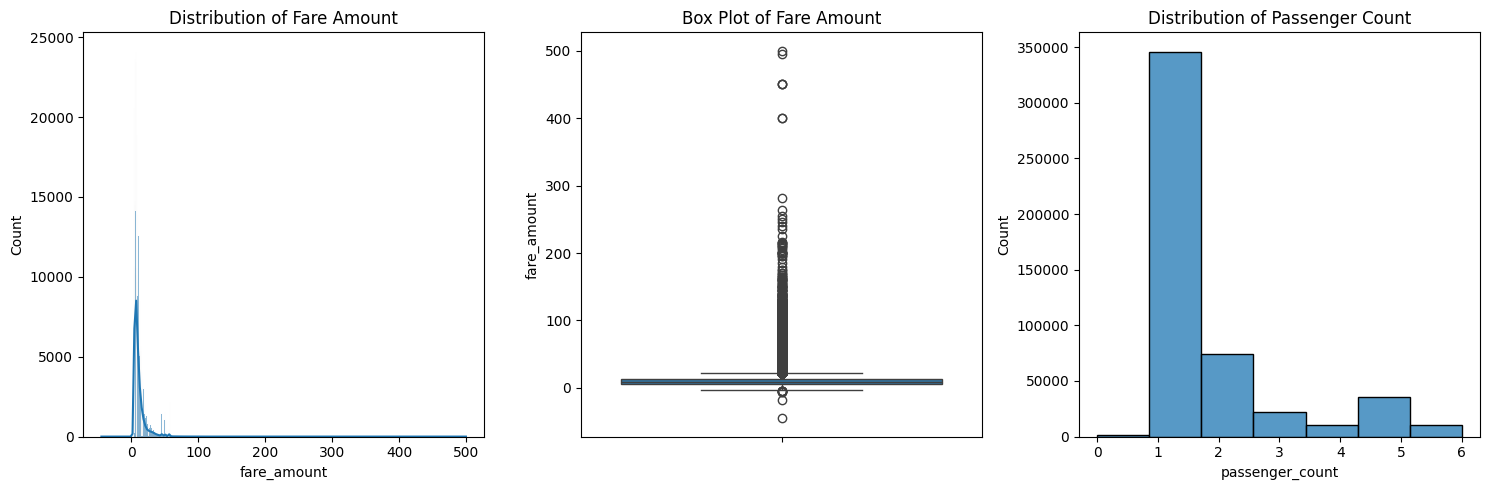

In [12]:
# Visualising Data
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['fare_amount'], kde=True)
plt.title('Distribution of Fare Amount')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['fare_amount'])
plt.title('Box Plot of Fare Amount')

plt.subplot(1, 3, 3)
sns.histplot(df['passenger_count'], bins=df['passenger_count'].nunique(), kde=False)
plt.title('Distribution of Passenger Count')

plt.tight_layout()
plt.show()

In [13]:
#preparing dataset for training
train_df,val_df = train_test_split(df, test_size=0.2, random_state=42)
len(train_df), len(val_df)

(399996, 99999)

In [14]:
#input/output coloumns
input_cols = ["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude", "passenger_count"]
target_col = "fare_amount"

In [15]:
train_inputs = train_df[input_cols]
train_targets = train_df[target_col]
val_inputs = val_df[input_cols]
val_targets = val_df[target_col]
test_inputs = test_df[input_cols]

In [16]:
train_inputs


,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
329952,-73.966949,40.761513,-74.006668,40.740593,1
261644,-73.975372,40.758911,-73.965050,40.758961,1
483559,-73.982559,40.755054,-74.013634,40.715458,1
85143,-73.982124,40.768970,-73.986588,40.770454,1
260336,-74.008423,40.725807,-73.991020,40.744564,3
...,...,...,...,...,...
259180,-73.952370,40.783920,-73.977135,40.729069,5
365841,-73.990395,40.728775,-73.867668,40.720261,5
131933,-73.953720,40.770943,-74.024971,40.641346,1
146868,-73.977928,40.753754,-73.993309,40.751450,1


In [17]:
train_targets

,fare_amount
329952,15.500000
261644,5.000000
483559,21.500000
85143,3.500000
260336,7.000000
...,...
259180,16.000000
365841,23.299999
131933,31.700001
146868,8.500000


In [18]:
val_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
104241,-73.783424,40.648525,-73.866890,40.767345,1
248977,-73.971664,40.746368,-73.960899,40.760986,3
140200,-73.979858,40.742073,-73.947556,40.745132,3
132815,-73.966309,40.772369,-73.927177,40.777443,2
499722,-73.965805,40.762859,-73.954170,40.764069,1
...,...,...,...,...,...
257912,-73.993614,40.761368,-74.010170,40.721054,5
66361,-74.001144,40.746338,-73.993416,40.737095,2
497229,-73.986763,40.756664,-73.991997,40.750610,1
152729,-73.960007,40.770504,-73.982109,40.778774,1


In [19]:
val_targets

,fare_amount
104241,27.700001
248977,6.000000
140200,11.300000
132815,8.500000
499722,6.500000
...,...
257912,12.100000
66361,5.700000
497229,4.000000
152729,2.900000


In [20]:
test_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,-73.973320,40.763805,-73.981430,40.743835,1
1,-73.986862,40.719383,-73.998886,40.739201,1
2,-73.982521,40.751259,-73.979652,40.746140,1
3,-73.981163,40.767807,-73.990448,40.751637,1
4,-73.966049,40.789776,-73.988564,40.744427,1
...,...,...,...,...,...
9909,-73.968124,40.796997,-73.955643,40.780388,6
9910,-73.945511,40.803600,-73.960213,40.776371,6
9911,-73.991600,40.726608,-73.789742,40.647011,6
9912,-73.985573,40.735432,-73.939178,40.801731,6


In [21]:
#train and evaluate hardcoded model
class MeanRegressor:
    def fit(self, inputs, targets) :
      self.mean = targets.mean ()
    def predict(self, inputs):
      return np.full(inputs.shape[0], self.mean)

mean_model = MeanRegressor()
mean_model. fit(train_inputs, train_targets)
mean_model.mean

np.float32(11.343229)

In [22]:
rmse = np.sqrt(mean_squared_error(train_targets, mean_model.predict(train_inputs)))
print(f"RMSE for MeanRegressor on training data: {rmse}")

RMSE for MeanRegressor on training data: 9.90612022724048


In [23]:
#Linear Regeression
linear_model = LinearRegression()
linear_model.fit(train_inputs, train_targets)
train_pred = linear_model.predict(train_inputs)
rmse_linear_train = np.sqrt(mean_squared_error(train_targets, train_pred))
print(f"RMSE for Linear Regression on training data: {rmse_linear_train}")

#prediction for validation data
val_pred = linear_model.predict(val_inputs)
rmse_linear_val = np.sqrt(mean_squared_error(val_targets, val_pred))
print(f"RMSE for Linear Regression on Validation data: {rmse_linear_val}")


RMSE for Linear Regression on training data: 9.904706094570612
RMSE for Linear Regression on Validation data: 9.95418199229561


In [24]:
#function to generate submission file
def predict_and_submit(model, test_inputs, fname):
    test_pred = model.predict(test_inputs)
    sub_df = pd.read_csv("/content/new-york-city-taxi-fare-prediction/sample_submission.csv")
    sub_df["fare_amount"] = test_pred
    sub_df.to_csv(fname, index=None)
    return sub_df
predict_and_submit(linear_model, test_inputs, "submission1.csv")


,key,fare_amount
0,2015-01-27 13:08:24.0000002,11.257445
1,2015-01-27 13:08:24.0000003,11.257514
2,2011-10-08 11:53:44.0000002,11.257459
3,2012-12-01 21:12:12.0000002,11.257364
4,2012-12-01 21:12:12.0000003,11.257362
...,...,...
9909,2015-05-10 12:37:51.0000002,11.791375
9910,2015-01-12 17:05:51.0000001,11.791409
9911,2015-04-19 20:44:15.0000001,11.792435
9912,2015-01-31 01:05:19.0000005,11.791493


In [25]:
#Feature Engineering
#splitting date time coloumn
def add_dateparts(df, col):
  df[col + "_year"] = df[col].dt.year
  df[col + "_month"] = df[col].dt.month
  df[col + "_day"] = df[col].dt.day
  df[col + "_weekday"] = df[col].dt.weekday
  df[col + "_hour"] = df[col].dt.hour
add_dateparts(train_df, "pickup_datetime")
add_dateparts(val_df, "pickup_datetime")
test_df["pickup_datetime"] = pd.to_datetime(test_df["pickup_datetime"], utc=True)
add_dateparts(test_df, "pickup_datetime")

In [26]:
#Distance between pickup (haversine formula)
def haversine_distance(df, start_lat, start_lon, end_lat, end_lon):
    lat1 = np.radians(df[start_lat])
    lon1 = np.radians(df[start_lon])
    lat2 = np.radians(df[end_lat])
    lon2 = np.radians(df[end_lon])
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    R = 6371  # Radius of Earth in kilometers
    distance = R * c

    return distance

In [27]:
#function to add distance to dataset
def add_distance_feature(df):
    df["distance"] = haversine_distance(df, "pickup_latitude", "pickup_longitude", "dropoff_latitude", "dropoff_longitude")
    return df

train_df = add_distance_feature(train_df)
val_df = add_distance_feature(val_df)
test_df = add_distance_feature(test_df)

In [28]:
#Distance between popular Landmark
jfkAirport_coord = (40.6413, -73.7781)
lgaAirport_coord = (40.7769, -73.8740)
ewrAirport_coord = (40.6895, -74.1745)
metMuseum_coord = (40.7794, -73.9632)
worldTradeCenter_coord = (40.7128, -74.0134)

def add_landmark(df):
    landmarks = {
        "jfkAirport": jfkAirport_coord,
        "lgaAirport": lgaAirport_coord,
        "ewrAirport": ewrAirport_coord,
        "metMuseum": metMuseum_coord,
        "worldTradeCenter": worldTradeCenter_coord
    }

    for name, coord in landmarks.items():
        landmark_lat, landmark_lon = coord

        # Create temporary columns in the DataFrame for the landmark coordinates
        df[name + "_latitude_temp"] = landmark_lat
        df[name + "_longitude_temp"] = landmark_lon

        # Calculate distance using haversine_distance function
        df[name + "_distance"] = haversine_distance(df,
                                                    "pickup_latitude",
                                                    "pickup_longitude",
                                                    name + "_latitude_temp",
                                                    name + "_longitude_temp")

        # Drop temporary columns
        df.drop(columns=[name + "_latitude_temp", name + "_longitude_temp"], inplace=True)
    return df

In [29]:
add_landmark(train_df)
add_landmark(val_df)
add_landmark(test_df)

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,distance,jfkAirport_distance,lgaAirport_distance,ewrAirport_distance,metMuseum_distance,worldTradeCenter_distance
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24+00:00,-73.973320,40.763805,-73.981430,40.743835,1,2015,1,27,1,13,2.323358,21.362866,8.489592,18.859167,1.932108,6.600744
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24+00:00,-73.986862,40.719383,-73.998886,40.739201,1,2015,1,27,1,13,2.425299,19.628674,11.458582,16.162102,6.965061,2.353237
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44+00:00,-73.982521,40.751259,-73.979652,40.746140,1,2011,10,8,5,11,0.618403,21.130357,9.573853,17.576230,3.526930,5.005774
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12+00:00,-73.981163,40.767807,-73.990448,40.751637,1,2012,12,1,5,21,1.960912,22.155569,9.080289,18.472637,1.987144,6.692564
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12+00:00,-73.966049,40.789776,-73.988564,40.744427,1,2012,12,1,5,21,5.387211,22.880233,7.881443,20.802617,1.178583,9.443088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9909,2015-05-10 12:37:51.0000002,2015-05-10 12:37:51+00:00,-73.968124,40.796997,-73.955643,40.780388,6,2015,5,10,6,12,2.124599,23.583585,8.233161,21.099028,2.000025,10.109260
9910,2015-01-12 17:05:51.0000001,2015-01-12 17:05:51+00:00,-73.945511,40.803600,-73.960213,40.776371,6,2015,1,12,0,17,3.271138,22.907212,6.712735,23.088652,3.075526,11.603308
9911,2015-04-19 20:44:15.0000001,2015-04-19 20:44:15+00:00,-73.991600,40.726608,-73.789742,40.647011,6,2015,4,19,6,20,19.183577,20.348478,11.375266,15.959657,6.338815,2.394549
9912,2015-01-31 01:05:19.0000005,2015-01-31 01:05:19+00:00,-73.985573,40.735432,-73.939178,40.801731,6,2015,1,31,5,1,8.343392,20.385478,10.467914,16.722815,5.239526,3.439875


In [30]:
#Remove outliers and Invalid data
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000
mean,11.358184,-72.520088,39.920361,-72.522423,39.916531,1.683445
std,9.915191,11.873084,8.045073,11.812584,7.388025,1.307391
min,-44.900002,-2986.242432,-3116.285400,-3383.296631,-2559.749023,0.000000
25%,6.000000,-73.992050,40.734917,-73.991379,40.734058,1.000000
50%,8.500000,-73.981789,40.752670,-73.980125,40.753151,1.000000
75%,12.500000,-73.967117,40.767075,-73.963570,40.768135,2.000000
max,500.000000,2140.601074,1703.092773,40.851028,404.616669,6.000000


In [31]:
test_df.describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,distance,jfkAirport_distance,lgaAirport_distance,ewrAirport_distance,metMuseum_distance,worldTradeCenter_distance
count,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000
mean,-73.974716,40.751041,-73.973656,40.751740,1.671273,2011.815816,6.857979,16.194170,2.852834,13.467420,3.435373,20.878760,9.745462,18.393125,4.404129,5.898551
std,0.042799,0.033542,0.039093,0.035436,1.278747,1.803347,3.353272,8.838482,1.994451,6.868584,3.972377,3.827190,3.479949,4.339491,4.282592,4.557325
min,-74.252190,40.573143,-74.263245,40.568974,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.417329,0.307081,11.526354,0.067383,0.145615
25%,-73.992500,40.736125,-73.991249,40.735253,1.000000,2010.000000,4.000000,9.000000,1.000000,8.000000,1.298076,20.572207,8.395535,16.332345,2.098632,3.422154
50%,-73.982327,40.753052,-73.980015,40.754065,1.000000,2012.000000,7.000000,16.000000,3.000000,15.000000,2.217041,21.200580,9.668722,17.788566,3.719764,5.421724
75%,-73.968012,40.767113,-73.964062,40.768757,2.000000,2014.000000,10.000000,25.000000,5.000000,19.000000,4.045591,21.887719,11.079759,19.491025,5.759632,7.448248
max,-72.986534,41.709557,-72.990967,41.696682,6.000000,2015.000000,12.000000,31.000000,6.000000,23.000000,99.996071,136.009490,127.516148,150.807660,131.775635,140.221219


In [32]:
def remove_outliers(df):
  return df [
      (df["fare_amount"] >= 1) &
      (df["fare_amount"] <= 500) &
      (df["passenger_count"] >= 1) &
      (df["passenger_count"] <= 6) &
      (df["pickup_longitude"] >= -75) &
      (df["pickup_longitude"] <= -72) &
      (df["pickup_latitude"] >= 40) &
      (df["pickup_latitude"] <= 42) &
      (df["dropoff_longitude"] >= -75) &
      (df["dropoff_longitude"] <= -72) &
      (df["dropoff_latitude"] >= 40) &
      (df["dropoff_latitude"] <= 42)
  ]

def remove_outliers_test(df):
  return df [
      (df["passenger_count"] >= 1) &
      (df["passenger_count"] <= 6) &
      (df["pickup_longitude"] >= -75) &
      (df["pickup_longitude"] <= -72) &
      (df["pickup_latitude"] >= 40) &
      (df["pickup_latitude"] <= 42) &
      (df["dropoff_longitude"] >= -75) &
      (df["dropoff_longitude"] <= -72) &
      (df["dropoff_latitude"] >= 40) &
      (df["dropoff_latitude"] <= 42)
  ]

train_df = remove_outliers(train_df)
val_df = remove_outliers(val_df)
test_df = remove_outliers_test(test_df)

In [33]:
#saving dataset to parquet format
train_df.to_parquet("train.parquet")
val_df.to_parquet("val.parquet")
test_df.to_parquet("test.parquet")

In [34]:
#Train and Evaluate Different model
input_cols = ["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude", "passenger_count", "distance", "jfkAirport_distance", "lgaAirport_distance", "ewrAirport_distance", "metMuseum_distance", "worldTradeCenter_distance"]
target_col = "fare_amount"
train_inputs = train_df[input_cols]
train_targets = train_df[target_col]
val_inputs = val_df[input_cols]
val_targets = val_df[target_col]
test_inputs = test_df[input_cols]

#Helper function to evaluate models
def evaluate_model(model):
    train_pred = model.predict(train_inputs)
    rmse_train = mean_squared_error(train_targets, train_pred, squared = False)
    val_pred = model.predict(val_inputs)
    rmse_val = mean_squared_error(val_targets, val_pred, squared = False)
    return rmse_train, rmse_val, train_pred, val_pred

In [35]:
#Train and Evaluate Different model
#Helper function to evaluate models
def evaluate_model(model):
    train_pred = model.predict(train_inputs)
    rmse_train = np.sqrt(mean_squared_error(train_targets, train_pred))
    val_pred = model.predict(val_inputs)
    rmse_val = np.sqrt(mean_squared_error(val_targets, val_pred))
    return rmse_train, rmse_val, train_pred, val_pred

#Ridge regression
ridge_model = Ridge(random_state=42, alpha=0.9)
ridge_model.fit(train_inputs, train_targets)
print(evaluate_model(ridge_model))
predict_and_submit(ridge_model, test_inputs, "ridgeModel.csv")

(np.float64(5.598773011866857), np.float64(5.603542169090893), array([11.84152394,  6.2079757 , 14.14411996, ..., 34.95322522,
        6.73870198, 13.42126473]), array([40.68669308,  8.35952866, 10.39584493, ...,  5.91244414,
        7.85459731, 10.0491254 ]))


,key,fare_amount
0,2015-01-27 13:08:24.0000002,8.811464
1,2015-01-27 13:08:24.0000003,8.891458
2,2011-10-08 11:53:44.0000002,5.726677
3,2012-12-01 21:12:12.0000002,7.984412
4,2012-12-01 21:12:12.0000003,14.815419
...,...,...
9909,2015-05-10 12:37:51.0000002,9.326999
9910,2015-01-12 17:05:51.0000001,12.235899
9911,2015-04-19 20:44:15.0000001,45.651598
9912,2015-01-31 01:05:19.0000005,20.647753


In [36]:
#Random Forest
RandomForestRegressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
RandomForestRegressor.fit(train_inputs, train_targets)
print(evaluate_model(RandomForestRegressor))

(np.float64(3.978738838157738), np.float64(4.357866107965063), array([12.76088326,  5.06886966, 15.21448369, ..., 38.23111747,
        6.7302612 , 13.3872538 ]), array([34.04188112,  8.12547653, 10.06501885, ...,  4.98380899,
        7.84105506, 10.23984709]))


In [37]:
predict_and_submit(ridge_model, test_inputs, "RandomForestModel.csv")

,key,fare_amount
0,2015-01-27 13:08:24.0000002,8.811464
1,2015-01-27 13:08:24.0000003,8.891458
2,2011-10-08 11:53:44.0000002,5.726677
3,2012-12-01 21:12:12.0000002,7.984412
4,2012-12-01 21:12:12.0000003,14.815419
...,...,...
9909,2015-05-10 12:37:51.0000002,9.326999
9910,2015-01-12 17:05:51.0000001,12.235899
9911,2015-04-19 20:44:15.0000001,45.651598
9912,2015-01-31 01:05:19.0000005,20.647753


In [38]:
#Gradient Boosting Model
xgb_model = XGBRegressor(n_estimators=200, max_depth=5, n_jobs = -1, objective="reg:squarederror", random_state=42)
xgb_model.fit(train_inputs, train_targets)
print(evaluate_model(xgb_model))
predict_and_submit(ridge_model, test_inputs, "XGBModel.csv")

(np.float64(3.7347268932334283), np.float64(4.406325535769327), array([13.8428955,  5.341563 , 15.236611 , ..., 36.709904 ,  7.4188585,
       12.768885 ], dtype=float32), array([31.504944 ,  7.5870295, 11.167102 , ...,  5.35486  ,  8.417782 ,
       10.14767  ], dtype=float32))


,key,fare_amount
0,2015-01-27 13:08:24.0000002,8.811464
1,2015-01-27 13:08:24.0000003,8.891458
2,2011-10-08 11:53:44.0000002,5.726677
3,2012-12-01 21:12:12.0000002,7.984412
4,2012-12-01 21:12:12.0000003,14.815419
...,...,...
9909,2015-05-10 12:37:51.0000002,9.326999
9910,2015-01-12 17:05:51.0000001,12.235899
9911,2015-04-19 20:44:15.0000001,45.651598
9912,2015-01-31 01:05:19.0000005,20.647753
